In [13]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

In [14]:
train = pd.read_csv(
    "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/test.csv"
)

attendance = pd.read_csv(
    "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Attendance_series.csv"
)

print(train.shape)
print(test.shape)
print(attendance.shape)

(12000, 18)
(3000, 17)
(1048575, 5)


In [15]:
attendance_features = attendance.groupby(
    "student_id"
).agg({
    "attendance_pct": [
        "mean",
        "min",
        "max",
        "std"
    ]
})

attendance_features.columns = [
    "att_mean",
    "att_min",
    "att_max",
    "att_std"
]

attendance_features = attendance_features.reset_index()

attendance_features.head()

,student_id,att_mean,att_min,att_max,att_std
0,STU00001,0.806669,0.1276,1.0,0.214452
1,STU00002,0.913447,0.1816,1.0,0.175171
2,STU00003,0.743041,0.1237,1.0,0.209314
3,STU00004,0.781174,0.1394,1.0,0.191048
4,STU00005,0.782371,0.1460,1.0,0.183122


In [16]:
train2 = train.merge(
    attendance_features,
    on="student_id",
    how="left"
)

test2 = test.merge(
    attendance_features,
    on="student_id",
    how="left"
)

print(train2.shape)
print(test2.shape)

(12000, 22)
(3000, 21)


In [17]:
notes = pd.read_csv(
    "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Counsellor_notes.csv"
)

print(notes.shape)
notes.head()

(15000, 2)


,student_id,counsellor_note
0,STU00001,Student is performing well. Follow-up required.
1,STU00002,Needs to improve focus in class. Action plan d...
2,STU00003,"Struggling slightly with core subjects, advise..."
3,STU00004,Student expressed some stress regarding course...
4,STU00005,Multiple backlogs. Demotivated. Action plan di...


In [18]:
notes["note_length"] = notes["counsellor_note"].str.len()

notes_features = notes[["student_id", "note_length"]]

In [19]:
train3 = train2.merge(
    notes_features,
    on="student_id",
    how="left"
)

test3 = test2.merge(
    notes_features,
    on="student_id",
    how="left"
)

print(train3.shape)
print(test3.shape)

(12000, 23)
(3000, 22)


In [20]:
X = train3.drop(
    columns=["dropout_risk", "student_id"]
)

y = train3["dropout_risk"]

X_test = test3.drop(
    columns=["student_id"]
)

In [21]:
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

for col in X.select_dtypes(exclude=["object"]).columns:
    X[col] = X[col].fillna(X[col].median())
    X_test[col] = X_test[col].fillna(X_test[col].median())

In [22]:
cat_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(cat_cols)

['branch', 'gender', 'hostel_status', 'family_income', 'parent_education']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=100
)


model.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

preds = model.predict(X_valid)

print(
    "Macro F1:",
    f1_score(y_valid, preds, average="macro")
)

0:	learn: 1.0636763	total: 87ms	remaining: 43.4s
100:	learn: 0.6219327	total: 2.71s	remaining: 10.7s
200:	learn: 0.5703594	total: 5.61s	remaining: 8.34s
300:	learn: 0.5222632	total: 8.53s	remaining: 5.64s
400:	learn: 0.4825143	total: 11.5s	remaining: 2.84s
499:	learn: 0.4463417	total: 14.3s	remaining: 0us
Macro F1: 0.6026519968725711


In [24]:
test_preds = model.predict(X_test)

print(test_preds[:10])

[[0]
 [0]
 [2]
 [0]
 [0]
 [0]
 [2]
 [0]
 [0]
 [0]]


In [25]:
submission = pd.DataFrame({
    "student_id": test2["student_id"],
    "dropout_risk": test_preds.astype(int).flatten()
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.shape)

submission.head()

(3000, 2)


,student_id,dropout_risk
0,STU03679,0
1,STU11070,0
2,STU13561,2
3,STU00061,0
4,STU02416,0


In [26]:
import os

print(os.listdir())

['submission.csv', '.virtual_documents', 'catboost_info']


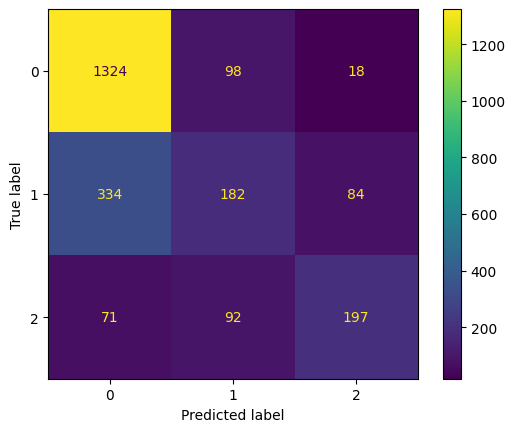

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.savefig("confusion_matrix.png")

plt.show()

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

              Feature  Importance
20        note_length   25.822063
3       family_income    6.021001
8   screen_time_hours    5.513899
16           att_mean    5.397131
4    parent_education    5.387497
10          cgpa_sem2    5.118445
17            att_min    4.922925
19            att_std    4.890905
0              branch    4.871887
7   commute_time_mins    4.834684


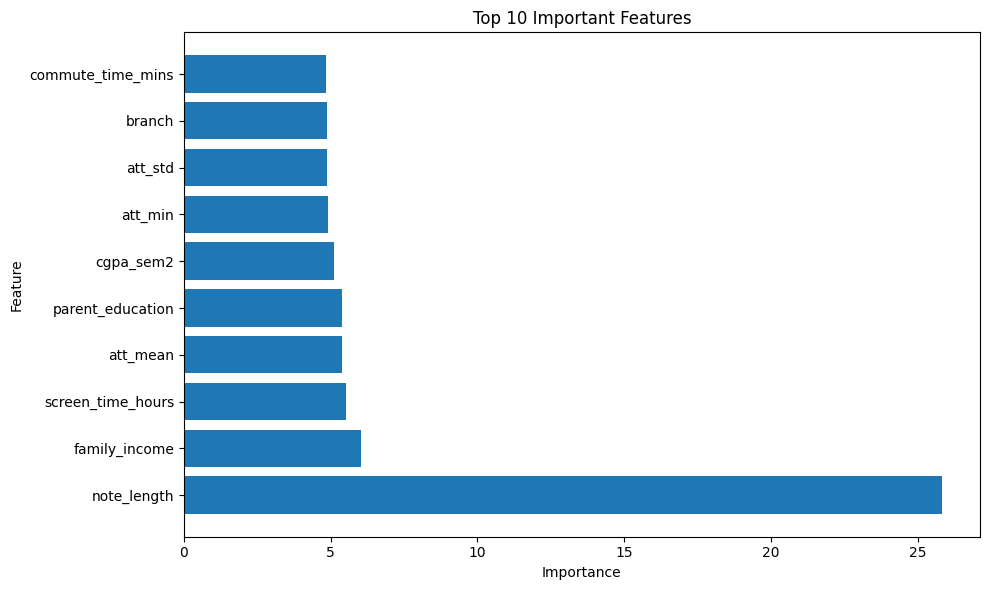

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, valid_idx in cv.split(X, y):

    X_train_cv = X.iloc[train_idx]
    X_valid_cv = X.iloc[valid_idx]

    y_train_cv = y.iloc[train_idx]
    y_valid_cv = y.iloc[valid_idx]

    model_cv = CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=42,
        verbose=0
    )

    model_cv.fit(
        X_train_cv,
        y_train_cv,
        cat_features=cat_cols
    )

    preds_cv = model_cv.predict(X_valid_cv)

    score = f1_score(
        y_valid_cv,
        preds_cv,
        average="macro"
    )

    scores.append(score)

print("Fold Scores:", scores)
print("Mean CV Score:", np.mean(scores))

Fold Scores: [0.6190379397625775, 0.6075875182462368, 0.6250478080008987, 0.6101682626777242, 0.6315957535347841]
Mean CV Score: 0.6186874564444442


In [31]:
dictionary = pd.read_csv(
    "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Data_dictionary.csv"
)

print(dictionary.shape)
dictionary.head(10)

(20, 4)


,file_name,column_name,data_type,description
0,complex_academic_data.csv,student_id,string,"Unique identifier for each student (e.g., STU0..."
1,complex_academic_data.csv,branch,categorical,"Engineering department (CSE, CSE-DS, IT, AIML,..."
2,complex_academic_data.csv,gender,categorical,"Student gender (M, F, Other)"
3,complex_academic_data.csv,hostel_status,categorical,"Living arrangement (Hostel, Day Scholar)"
4,complex_academic_data.csv,family_income,categorical,"Family income bracket (Low, Medium, High)"
5,complex_academic_data.csv,parent_education,categorical,Highest education level of parents (High Schoo...
6,complex_academic_data.csv,scholarship,binary,"1 = receives scholarship, 0 = no scholarship"
7,complex_academic_data.csv,part_time_job,binary,"1 = has part-time job, 0 = no part-time job"
8,complex_academic_data.csv,commute_time_mins,float,Estimated daily commute time in minutes. Conta...
9,complex_academic_data.csv,screen_time_hours,float,Estimated daily screen time in hours.
